1. divide my data to 5 year non-overlapping window in age (people 20-24, 25-29, 30-34 etc.)

2. Per ROI, and per age window, I want to find the slope of birth year (b1)
the regression model is:

for age_window:

GMV_ROI_1 ~ b1*birth_year

3. after calculating all b1 for all age windows, I want to present them in a plot (y axis is GMV, x axisis birth year).

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import statsmodels.formula.api as smf
from tqdm import tqdm

In [2]:
combined_df = pd.read_pickle('/home/gaia/Projects/legacy_data/combined_gm_volumes.pkl')
 
# keep only classification_label=1 and snbb
volumes = combined_df[(combined_df['classification_label'] == 1) | (combined_df['source'] == 'snbb')]


In [3]:

# divide volumes into age bins according to bin size
bin_size = 5
volumes['age_bin'] = pd.cut(volumes['age_in_years'], bins=np.arange(15, 85, bin_size))

print(f"amount of scans in each bin:")
print(volumes['age_bin'].value_counts().sort_index())

bin_list = volumes['age_bin'].cat.categories.tolist()


amount of scans in each bin:
age_bin
(15, 20]     65376
(20, 25]    579758
(25, 30]    652398
(30, 35]    344132
(35, 40]    182962
(40, 45]    138016
(45, 50]     77634
(50, 55]     50394
(55, 60]     41314
(60, 65]     35412
(65, 70]     23608
(70, 75]     11804
(75, 80]      4994
Name: count, dtype: int64


/tmp/ipykernel_4972/1693877541.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  volumes['age_bin'] = pd.cut(volumes['age_in_years'], bins=np.arange(15, 85, bin_size))


In [4]:
# add region name according to the atlas 
atlas_csv = pd.read_csv("/home/gaia/Projects/legacy_data/my_master/space-MNI152_atlas-schaefer2018tian2020_res-1mm_den-400_div-7networks_dseg.csv")
import pandas as pd
import statsmodels.formula.api as smf
from tqdm import tqdm

In [5]:
# initiate a df with the columns bin, region_label, birth_year_coef, birth_year_t, birth_year_p
coef_df = pd.DataFrame(columns=['age_bin', 'region_label', 'variable', 'coef', 't', 'p', 'fdr_p', 'region_name'])

for bin in volumes['age_bin'].unique().dropna():
    print(f"age bin: {bin}, number of scans: {volumes[volumes['age_bin'] == bin].shape[0]}")

    min_age = bin.left
    max_age = bin.right

    # volumes df
    df_bin = volumes[(volumes['age_in_years'] >= min_age) & (volumes['age_in_years'] < max_age)]

    # metadata df
    # remove duplicates based on subject_id
    metadata = volumes.drop_duplicates(subset=['subject_id'])
    print(f"shape of {min_age} - {max_age} years old metadata after removing duplicates: {metadata.shape}")



    # create a multiple regression model for each ROI
    results = []

    # Loop over regions (ROI-level analyses)
    for roi, df_roi in tqdm(df_bin.groupby('region_label')):
        # Fit model with birth_year as a continuous predictor
        model = smf.ols(
            'volume_mm3 ~ birth_year + C(sex) + tiv + age_in_years',
            data=df_roi
        ).fit()
        
        # Collect stats for each variable
        for var in model.params.index:
            results.append({
                'region_label': roi,
                'variable': var,
                'coef': model.params[var],
                't': model.tvalues[var],
                'p': model.pvalues[var]
            })

    results_df = pd.DataFrame(results)

    results_df = results_df.merge(
        atlas_csv[['index', 'name']],     # only keep relevant columns
        how='left',                      # keep all rows from results_df
        left_on='region_label',          # column in results_df
        right_on='index'                 # matching column in atlas_csv
    )

    # rename and clean up
    results_df.rename(columns={'name': 'region_name'}, inplace=True)
    results_df.drop(columns='index', inplace=True)

    # --- Multiple comparison correction (using results_df) ---
    from statsmodels.stats.multitest import multipletests

    cov_of_interest = 'birth_year'
    mask = results_df['variable'] == cov_of_interest
    _, fdr_p, _, _ = multipletests(results_df.loc[mask, 'p'], method='fdr_bh')
    results_df.loc[mask, 'fdr_p'] = fdr_p

    # sort for inspection
    results_df = results_df.sort_values(by='fdr_p')
    print(results_df.head())


    # make sure fdr_p is float 
    results_df['fdr_p'] = results_df['fdr_p'].astype(float)

    results_df['age_bin'] = bin
    coef_df = pd.concat([coef_df, results_df], ignore_index=True)

    # save the rows from results_df where fdr_p < 0.05
    significant_results_df = results_df[results_df['fdr_p'] < 0.05].copy()

    # increase in volume (t>0)
    print(significant_results_df.loc[significant_results_df['t'] > 0, 'region_name'].tolist())

    # decrease
    print(significant_results_df.loc[significant_results_df['t'] < 0, 'region_name'].tolist())

age bin: (20, 25], number of scans: 579758
shape of 20 - 25 years old metadata after removing duplicates: (3688, 26)


 71%|███████▏  | 324/454 [00:58<00:23,  5.50it/s]


KeyboardInterrupt: 

In [ ]:
birth_year_coef_df = coef_df[coef_df['variable'] == 'birth_year'].copy()


In [ ]:
# birth_year_coef_df.to_csv(f"/home/gaia/Projects/legacy_data/legacy_pipe/data/interim/birth_year_coef_df_age_bins_size_{bin_size}.csv", index=False)
coef_df.to_csv(f"/home/gaia/Projects/legacy_data/legacy_pipe/data/interim/coef_df_age_bins_size_{bin_size}.csv", index=False)

# Add weights to the coef according to how good the model is (how precise the the coef)
# use WLS model


In [ ]:
# calculate the weight for each coef based on 

In [ ]:
# Build the WLS plot for each ROI


# Visualization

Trends per ROI 

Region 421 - Coef vs Age Bin Regression Summary:
                            OLS Regression Results                            
Dep. Variable:                   coef   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                 -0.056
Method:                 Least Squares   F-statistic:                    0.3641
Date:                Tue, 03 Feb 2026   Prob (F-statistic):              0.558
Time:                        17:13:30   Log-Likelihood:                -70.992
No. Observations:                  13   AIC:                             146.0
Df Residuals:                      11   BIC:                             147.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
I

/home/gaia/Projects/legacy_data/venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=13 observations were given.
  return hypotest_fun_in(*args, **kwds)


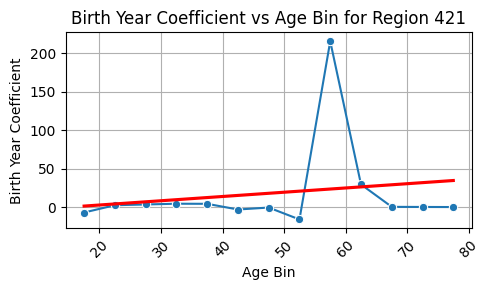

Region 422 - Coef vs Age Bin Regression Summary:
                            OLS Regression Results                            
Dep. Variable:                   coef   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                 -0.026
Method:                 Least Squares   F-statistic:                    0.6928
Date:                Tue, 03 Feb 2026   Prob (F-statistic):              0.423
Time:                        17:13:30   Log-Likelihood:                -74.006
No. Observations:                  13   AIC:                             152.0
Df Residuals:                      11   BIC:                             153.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
I

/home/gaia/Projects/legacy_data/venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=13 observations were given.
  return hypotest_fun_in(*args, **kwds)


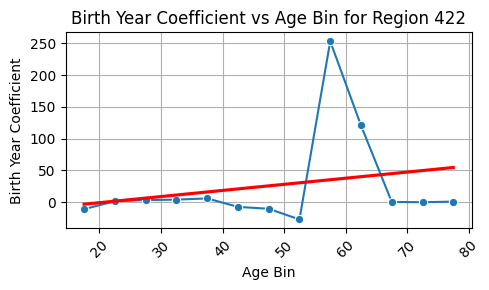

Region 448 - Coef vs Age Bin Regression Summary:
                            OLS Regression Results                            
Dep. Variable:                   coef   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                 -0.082
Method:                 Least Squares   F-statistic:                   0.09540
Date:                Tue, 03 Feb 2026   Prob (F-statistic):              0.763
Time:                        17:13:30   Log-Likelihood:                -73.313
No. Observations:                  13   AIC:                             150.6
Df Residuals:                      11   BIC:                             151.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
I

/home/gaia/Projects/legacy_data/venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=13 observations were given.
  return hypotest_fun_in(*args, **kwds)


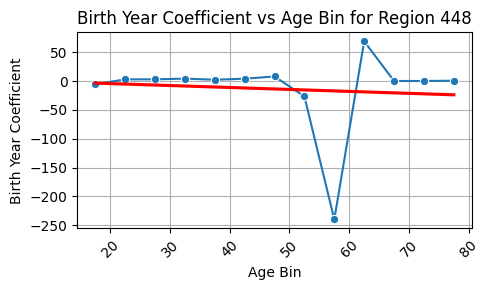

Region 449 - Coef vs Age Bin Regression Summary:
                            OLS Regression Results                            
Dep. Variable:                   coef   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.091
Method:                 Least Squares   F-statistic:                 2.763e-06
Date:                Tue, 03 Feb 2026   Prob (F-statistic):              0.999
Time:                        17:13:30   Log-Likelihood:                -66.196
No. Observations:                  13   AIC:                             136.4
Df Residuals:                      11   BIC:                             137.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
I

/home/gaia/Projects/legacy_data/venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=13 observations were given.
  return hypotest_fun_in(*args, **kwds)


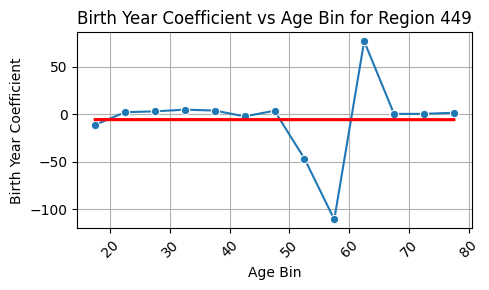

In [ ]:
birth_year_coef_df['mid_age_bin'] = birth_year_coef_df['age_bin'].apply(lambda x: x.mid)

# plot coef vs age bin for a specific region
# all of them, list from 1 to 454
# roi_list = list(range(1, 455))
roi_list = [421,422,448,449]

for region_of_interest in roi_list:
    region_data = birth_year_coef_df[birth_year_coef_df['region_label'] == region_of_interest]
    # calculate liner regression line
    if region_data.shape[0] < 2:
        print(f"Not enough data points for region {region_of_interest} to plot.")
        continue
    model = smf.ols('coef ~ mid_age_bin', data=region_data).fit()
    print(f"Region {region_of_interest} - Coef vs Age Bin Regression Summary:")
    print(model.summary())

    # plot
    plt.figure(figsize=(5, 3))
    sns.lineplot(
        data=region_data,
        x='mid_age_bin',
        y='coef',
        marker='o'
    )
    # add the regression line 
    sns.regplot(
        data=region_data,
        x='mid_age_bin',
        y='coef',
        scatter=False,
        ci=None,
        line_kws={'color': 'red', 'label': 'Linear Fit'}
    )
    plt.title(f'Birth Year Coefficient vs Age Bin for Region {region_of_interest}')
    plt.xlabel('Age Bin')
    plt.ylabel('Birth Year Coefficient')
    plt.xticks(rotation=45)
    plt.grid()
    plt.tight_layout()
    plt.show()

Linear regression and on to the brain 
The slope of birth year in each age window 
the effect of birth year in each age window

Mapping 1146 significant coef...
Created coef-map image for visualization.


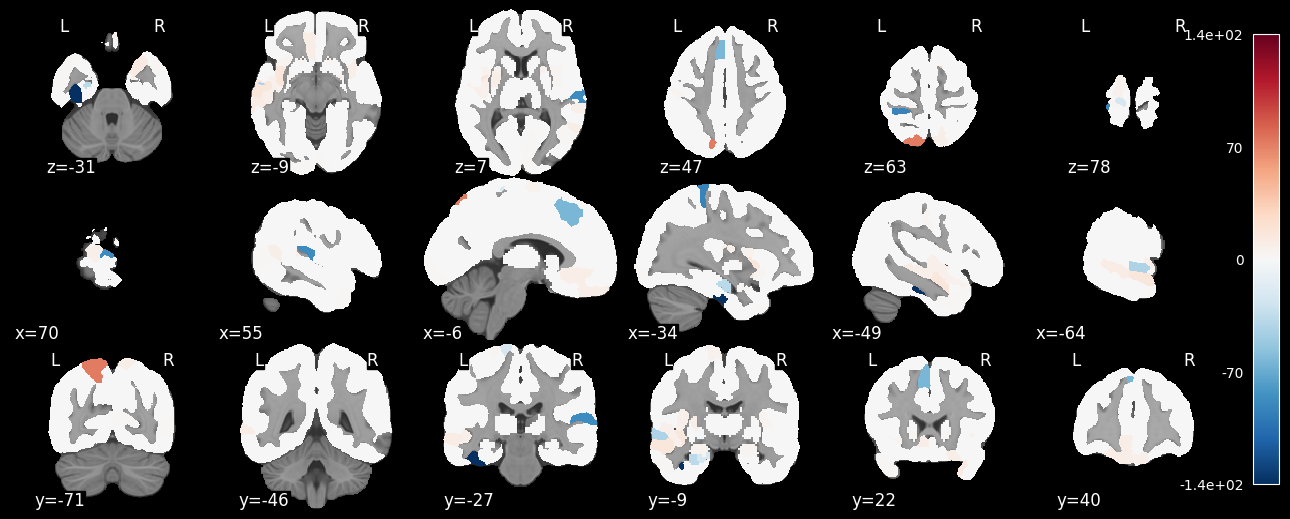

In [ ]:
# visualization of significant results on the brain, birth_year

import numpy as np
import nibabel as nib
from nilearn import plotting
from nilearn.image import new_img_like
from nilearn.datasets import load_mni152_template # for background image

# --- 1. Load Your Atlas ---
atlas_file_path = '/media/storage/MATLAB_atlases-20250612T134418Z-1-001/MATLAB_atlases/schaefer2018tian2020_400_7.nii'
atlas_img = nib.load(atlas_file_path)
atlas_labels = atlas_img.get_fdata()


# --- 2. Extract significant T-values from your results_df ---
significant_rois_data = birth_year_coef_df[(birth_year_coef_df['fdr_p'] < 0.05)][['region_label', 'coef']].values.tolist()
# Create a dictionary for quick lookup of T-values by ROI label
coef_map = {label: coef_val for label, coef_val in significant_rois_data}


# --- 3. Create the full statistical map ---

# 1. Initialize the statistical map array to zeros.
# This ensures that all non-significant ROIs (and the background 0) are set to T=0.
stat_map_data = np.zeros_like(atlas_labels, dtype=float)

# 2. Iterate over the significant ROIs and map their T-value.
print(f"Mapping {len(significant_rois_data)} significant coef...")
for label, coef_value in coef_map.items():
    # Find all voxels in the atlas that match the current ROI label and set their value in the stat_map_data to the T-value
    stat_map_data[atlas_labels == label] = coef_value
# 3. Create the final NIfTI image for visualization.
# This ensures the coef-map has the same spatial dimensions and coordinates as your atlas.
coef_map_img = new_img_like(atlas_img, stat_map_data)
print("Created coef-map image for visualization.")


# --- 4. Load background template ---
bg_img = load_mni152_template()

# --- 5. Plot the coef-map ---
custom_cut_coords = (6,6,6)

# Plot the coef-map using the mosaic display mode
plotting.plot_stat_map(
    stat_map_img=coef_map_img,
    bg_img=bg_img,
    # title=f"ROI T-Values",
    cmap='RdBu_r',
    symmetric_cbar=True,
    threshold=0.01,
    display_mode='mosaic',
    cut_coords=custom_cut_coords,
    colorbar=True
)


# Display the plot
plotting.show()

In [ ]:
# make a regression model for each region to see if there is a trend in coef vs age bin
trend_results = []
for region_of_interest in roi_list:
    region_data = birth_year_coef_df[birth_year_coef_df['region_label'] == region_of_interest]
    
    if region_data.shape[0] < 2:
        continue  # Skip regions with insufficient data points

    # Fit linear regression model: coef ~ mid_age_bin
    model = smf.ols('coef ~ mid_age_bin', data=region_data).fit()
    
    trend_results.append({
        'region_label': region_of_interest,
        'slope': model.params['mid_age_bin'],
        't': model.tvalues['mid_age_bin'],
        'p': model.pvalues['mid_age_bin']
    })
trend_results_df = pd.DataFrame(trend_results)
# FDR Multiple comparison correction
from statsmodels.stats.multitest import multipletests
_, fdr_p, _, _ = multipletests(trend_results_df['p'], method='fdr_bh')
trend_results_df['fdr_p'] = fdr_p
trend_results_df = trend_results_df.sort_values(by='fdr_p')
print(trend_results_df.head())

# plot the regression lines for significant regions
significant_trends = trend_results_df[trend_results_df['fdr_p'] < 0.05]
print(f"Significant trends found in regions: {significant_trends['region_label'].tolist()}")

for _, row in significant_trends.iterrows():
    region_of_interest = row['region_label']
    region_data = birth_year_coef_df[birth_year_coef_df['region_label'] == region_of_interest]
    
    plt.figure(figsize=(5, 3))
    sns.regplot(
        data=region_data,
        x='mid_age_bin',
        y='coef',
        ci=None,
        line_kws={'color': 'red'}
    )
    plt.title(f'Trend in Birth Year Coefficient vs Age Bin for Region {region_of_interest}')
    plt.xlabel('Age Bin')
    plt.ylabel('Birth Year Coefficient')
    plt.xticks(rotation=45)
    plt.grid()
    plt.tight_layout()
    plt.show()

   region_label     slope         t         p     fdr_p
0           421  0.553711  0.603410  0.558473  0.998704
1           422  0.963117  0.832371  0.422903  0.998704
2           448 -0.338848 -0.308876  0.763187  0.998704
3           449 -0.001055 -0.001662  0.998704  0.998704
Significant trends found in regions: []
